<a href="https://colab.research.google.com/github/pmolinari2910/Modelizado-de-IA/blob/main/Copia_de_Practica_Unidad_2_Molinari_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [2]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 25.9 MB/s eta 0:00:00


In [3]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

----------------------------------------
             CRONOGRAMA OPTIMIZADO
----------------------------------------
Tarea 0: Días 07 al 12 | Operarios: 4
Tarea 1: Días 05 al 12 | Operarios: 6
Tarea 2: Días 00 al 04 | Operarios: 5
Tarea 3: Días 12 al 18 | Operarios: 3
Tarea 4: Días 13 al 18 | Operarios: 4
Tarea 5: Días 03 al 07 | Operarios: 3
Tarea 6: Días 00 al 03 | Operarios: 2
Tarea 7: Días 00 al 02 | Operarios: 3
Tarea 8: Días 14 al 18 | Operarios: 2
Tarea 9: Días 03 al 05 | Operarios: 2
----------------------------------------
Duración final de la obra: 18 días
Fitness alcanzado: 0.055525
----------------------------------------


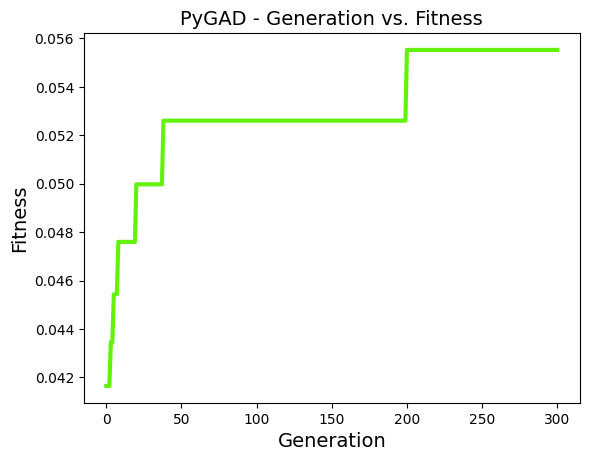

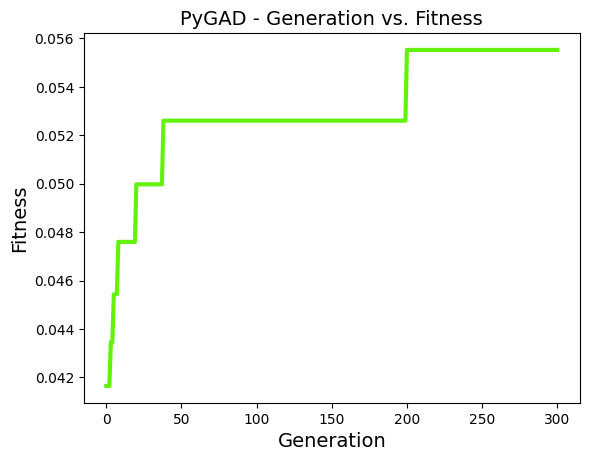

In [7]:
# 1. Modelado de Datos
TASAS_OBRA = {
    0: (5, 4), 1: (7, 6), 2: (4, 5), 3: (6, 3), 4: (5, 4),
    5: (4, 3), 6: (3, 2), 7: (2, 3), 8: (4, 2), 9: (2, 2)
}
MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

# 2. Función de Fitness Estricta
def fitness_func(ga_instance, solution, solution_idx):
    tiempos_inicio = np.maximum(0, np.round(solution).astype(int))
    tiempos_fin = [tiempos_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]
    makespan = max(tiempos_fin)

    penalizacion = 0
    for dia in range(makespan):
        operarios_en_dia = 0
        for i in range(NUM_TAREAS):
            if tiempos_inicio[i] <= dia < tiempos_fin[i]:
                operarios_en_dia += TASAS_OBRA[i][1]

        if operarios_en_dia > MAX_OPERARIOS:
            # Penalización progresiva para que el algoritmo pueda "aprender" de los errores cercanos
            penalizacion += 200 * (operarios_en_dia - MAX_OPERARIOS)

    # El fitness mejora a menor makespan y menor penalización
    fitness = 1.0 / (makespan + penalizacion + 0.01)
    return fitness

# Ajuste del espacio de búsqueda para obligar al solapamiento inteligente
MAX_DIA_INICIO_ESTIMADO = 20

# 3. Configuración del GA para lograr el efecto "Escalera"
ga_instance = pygad.GA(
    num_generations=300,          # Más generaciones permiten ver los momentos de estabilidad y salto
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=100,              # Población más grande = más diversidad inicial
    num_genes=NUM_TAREAS,
    gene_type=int,

    init_range_low=0,
    init_range_high=MAX_DIA_INICIO_ESTIMADO,

    # Selección por torneo estable
    parent_selection_type="tournament",
    K_tournament=3,

    # Cruce de dos puntos para combinar mejor los bloques de tareas viables
    crossover_type="two_points",

    # CLAVE PARA LA ESCALERA: Mutación adaptativa o controlada
    # Usamos "scramble" o "random" pero con un porcentaje bajo de genes afectados.
    # Así, la mayoría del cronograma se mantiene igual y solo muta un detalle.
    mutation_type="random",
    mutation_percent_genes=10,    # Reducido al 10% para ajustes finos
    random_mutation_min_val=-3,   # Permite que las tareas se muevan sutilmente
    random_mutation_max_val=3,    # hacia atrás o adelante respecto a su posición actual

    # Elitismo fuerte: Preserva el escalón actual sin dejar que empeore
    keep_parents=5
)

# Callback opcional para forzar a los genes a mantenerse en rangos positivos durante la mutación
def on_generation(ga_instance):
    # Asegura que las mutaciones no generen días de inicio negativos
    for ind in range(ga_instance.population.shape[0]):
        ga_instance.population[ind] = np.maximum(0, ga_instance.population[ind])

ga_instance.on_generation = on_generation

# 4. Ejecución
ga_instance.run()

# --- Análisis de Resultados ---
solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("-" * 40)
print("             CRONOGRAMA OPTIMIZADO")
print("-" * 40)

tiempos_inicio = np.maximum(0, np.round(solution).astype(int))
tiempos_fin = [tiempos_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]
makespan_optimo = max(tiempos_fin)

for i in range(NUM_TAREAS):
    print(f"Tarea {i}: Días {tiempos_inicio[i]:02d} al {tiempos_fin[i]:02d} | Operarios: {TASAS_OBRA[i][1]}")

print("-" * 40)
print(f"Duración final de la obra: {makespan_optimo} días")
print(f"Fitness alcanzado: {solution_fitness:.6f}")
print("-" * 40)

# Graficar la evolución (Aquí vas a ver los escalones claros)
ga_instance.plot_fitness()

## Si usan DEAP:

In [6]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt